# Assignment 1

## *How should I price auto insurance in the United States?*

## Introduction

**Business Context.** The ability to price an insurance quote properly has a significant impact on insurers' management decisions and financial statements. You are the chief data scientist at a new startup insurance company focusing on providing affordable insurance to millennials. You are tasked to assess the current state of insurance companies to see what factors large insurance providers charge premiums for. Fortunately for you, your company has compiled a dataset by surveying what people currently pay for insurance from large companies. Your findings will be used as the basis of developing your company's millenial car insurance offering. 

**Business Problem.** Your task is to build a **minimal** model to predict the cost of insurance from the data set using various characteristics of a policyholder.

**Analytical Context.** The data resides in a CSV file which has been pre-cleaned for you and can directly be read in. Throughout the case, you will be iterating on your initial model many times based on common pitfalls that arise which we discussed in previous cases. You will be using the Python `statsmodels` package to create and analyze these linear models.

In [1]:
### Load relevant packages

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
import statsmodels.api         as sm
import statsmodels.formula.api as smf
import os

# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

## Diving into the data

In [2]:
df = pd.read_csv('Allstate-cost-cleaned.csv',
    dtype = { # indicate categorical variables
        'A': 'category',
        'B': 'category',
        'C': 'category',
        'D': 'category',
        'E': 'category',
        'F': 'category',
        'G': 'category',
        'car_value': 'category',
        'state': 'category'
    }
)


The following are the columns in the dataset:

1. **state**: State where shopping point occurred
2. **group_size**: How many people will be covered under the policy (1, 2, 3 or 4) 
3. **homeowner**: Whether the customer owns a home (0=no, 1=yes)
4. **car_age**: Age of the customer's car (How old the car is)
5. **car_value**: Value of the car when it was new
6. **risk_factor**: An ordinal assessment of how risky the customer is (0,1, 2, 3, 4) 
7. **age_oldest**: Age of the oldest person in customer's group
8. **age_youngest**: Age of the youngest person in customer's group
9. **married_couple**: Does the customer group contain a married couple (0=no, 1=yes) 
10. **C_previous**: What the customer formerly had or currently has for product option C (0=nothing, 1, 2, 3,4)
11. **duration_previous**: How long (in years) the customer was covered by their previous issuer
12. **A,B,C,D,E,F,G**: The coverage options:
13. **A**: Collision (levels: 0, 1, 2);
14. **B**: Towing (levels: 0, 1);
15. **C**: Bodily Injury (BI, levels: 1, 2, 3, 4);
16. **D**: Property Damage (PD, levels 1, 2, 3);
17. **E**: Rental Reimbursement (RR, levels: 0, 1);
18. **F**: Comprehensive (Comp, levels: 0, 1, 2, 3);
19. **G**: Medical/Personal Injury Protection (Med/PIP, levels: 1, 2, 3, 4)
20. **cost**: cost of the quoted coverage options 

In [3]:
df.head(10)

,Unnamed: 0,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,0,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,0,0,1,1,0,0,4,543
1,1,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,2,1,1,3,1,3,2,611
2,2,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,691
3,3,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,695
4,4,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,1,1,0,2,2,628
5,5,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,2,1,0,2,2,625
6,6,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,2,1,0,2,2,628
7,7,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,0,0,1,1,0,0,2,596
8,8,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,2,0,1,1,0,3,2,711
9,9,OK,1,0,13,f,3.0,22,22,0,0.0,0.0,2,0,1,1,0,3,2,722


### Exercise 1:

Write code to visualize the relationship between cost and the following variables. Choose your plots judiciously based on what you know about each variable. Different variable types (categorical vs. numerical) should have different types of plots (e.g. scatter, boxplot, violin plot, etc.) Group your plots together using the `plt.subplot()` function.

1. `car_age`
2. `age_oldest`
3. `age_youngest`
4. `duration_previous`
5. `C_previous`
6. `homeowner`
7. `group_size`
8. `car_age`
9. Categories A-G (7 different plots)

**Answer.**

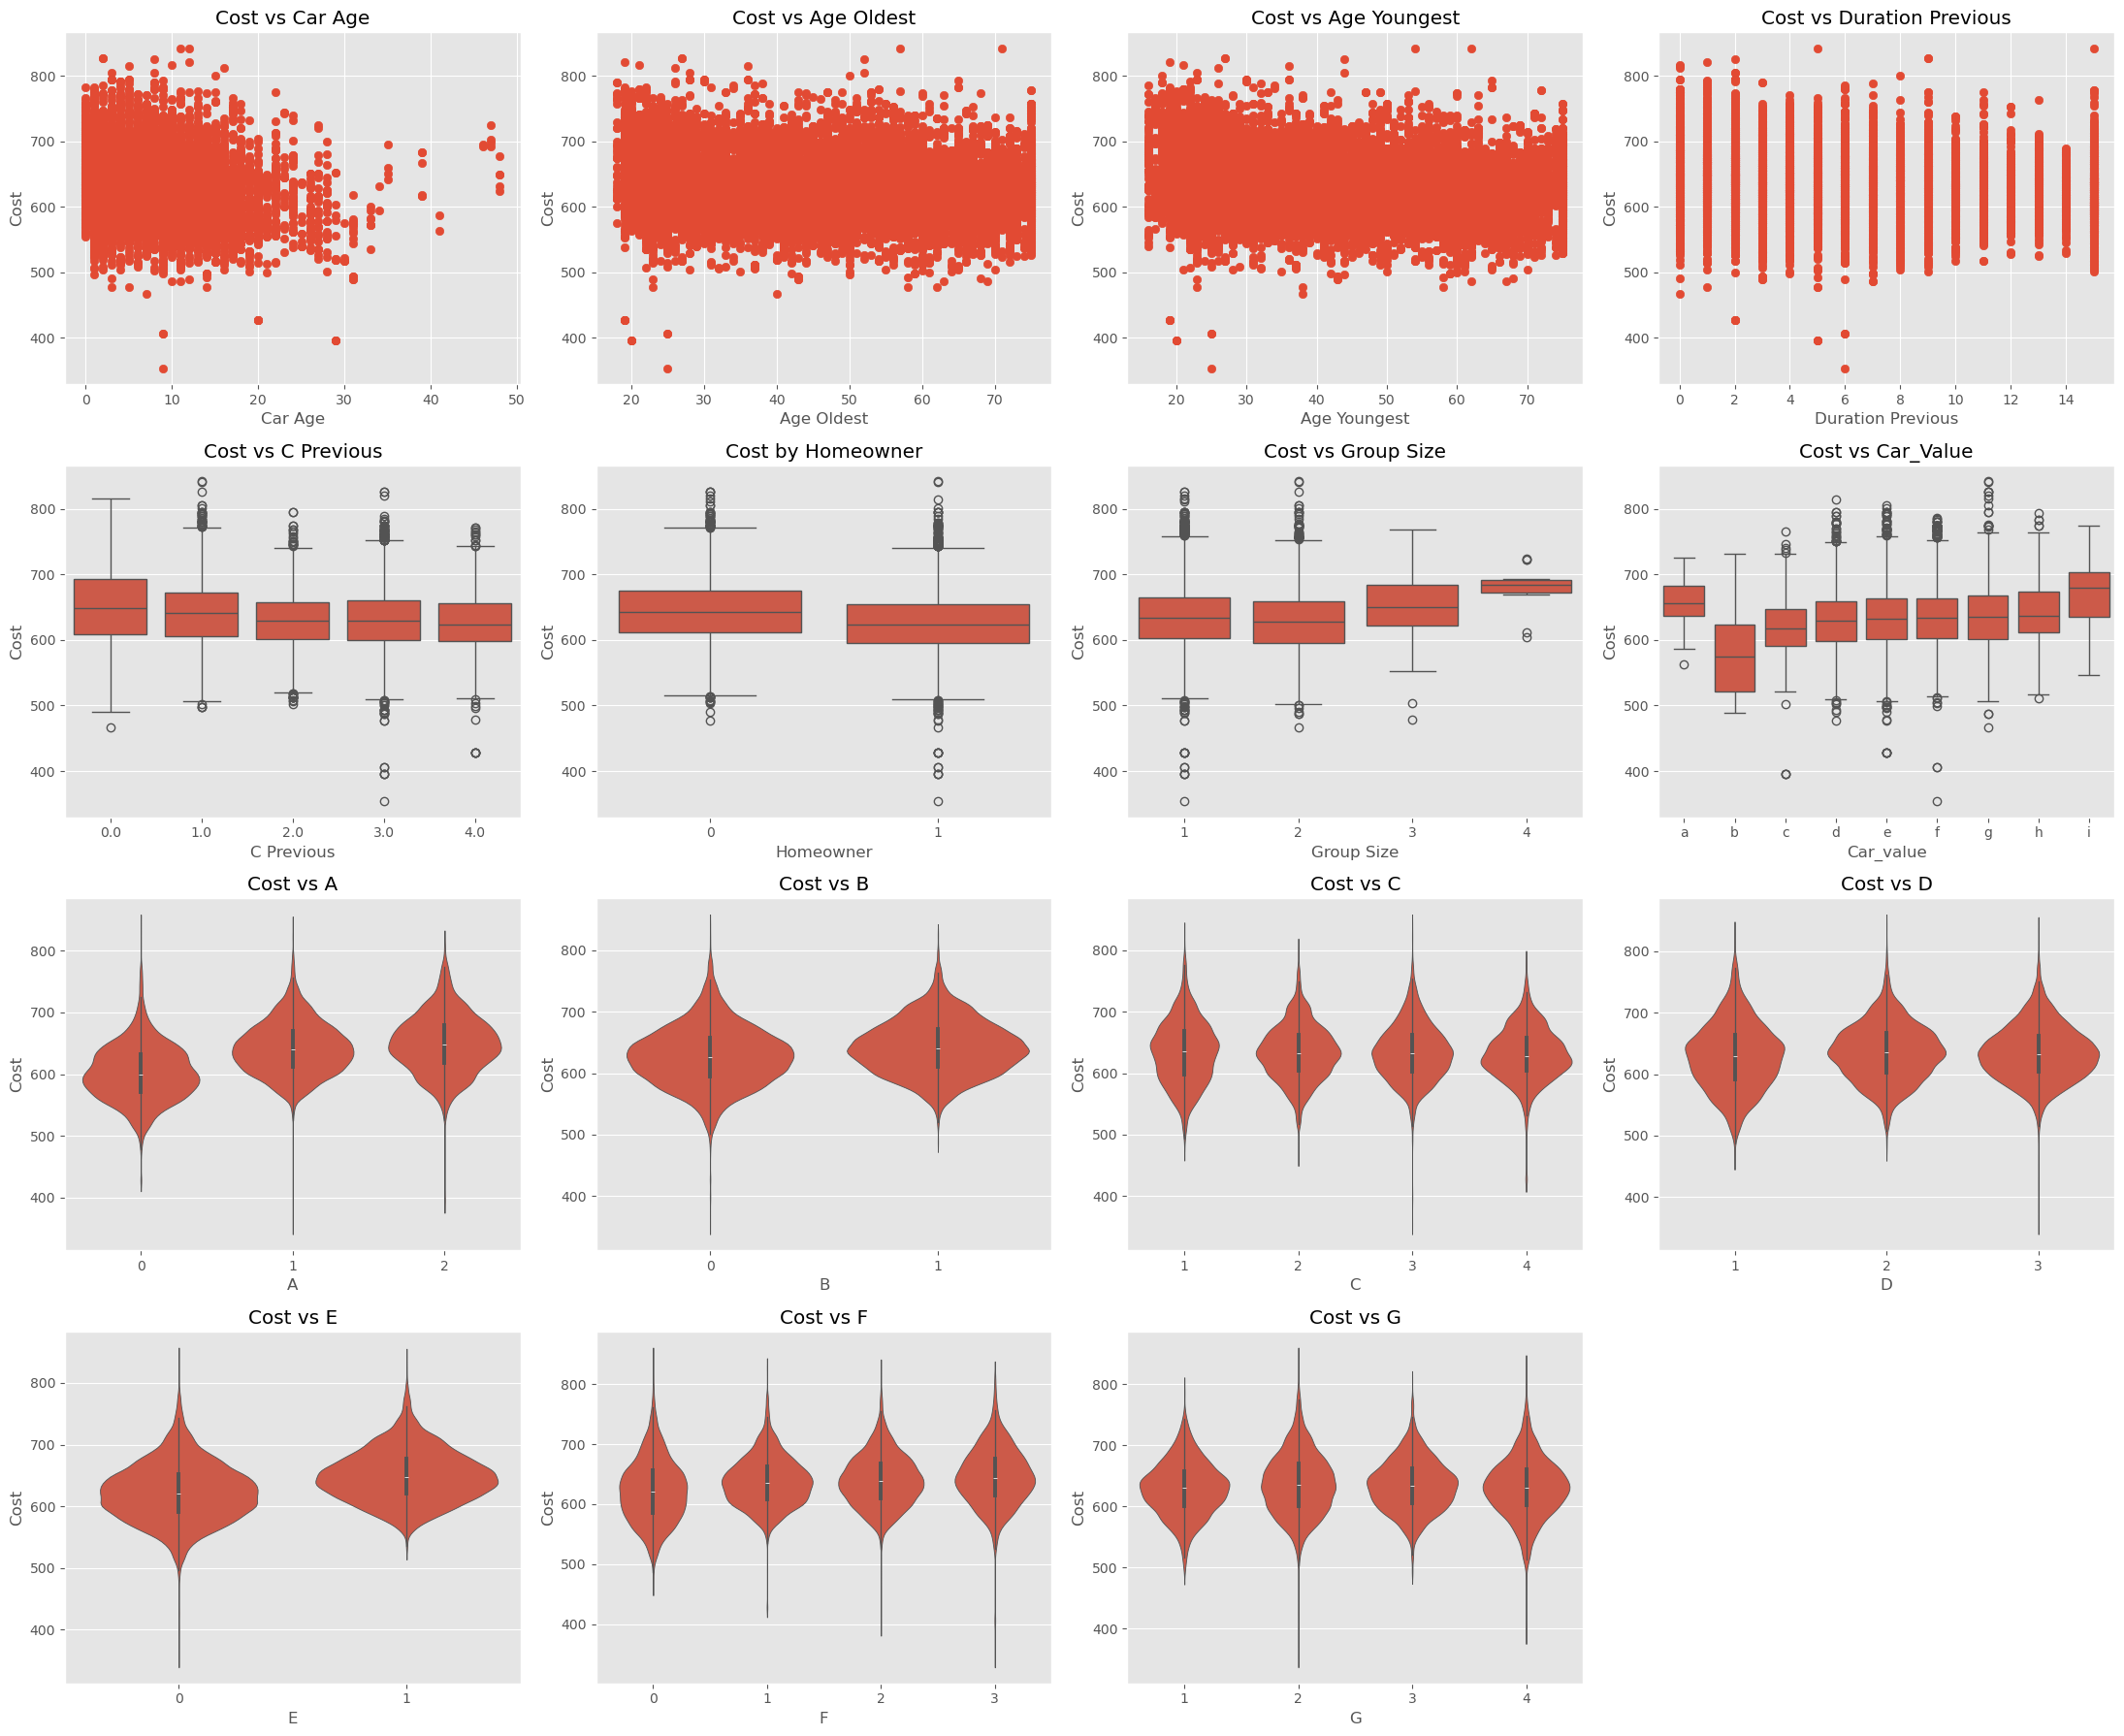

In [4]:
plt.figure(figsize=(22,18))

# 1️⃣ car_age
plt.subplot(4, 4, 1)
plt.scatter(df['car_age'], df['cost'])
plt.xlabel('Car Age')
plt.ylabel('Cost')
plt.title('Cost vs Car Age')

# 2️⃣ age_oldest
plt.subplot(4, 4, 2)
plt.scatter(df['age_oldest'], df['cost'])
plt.xlabel('Age Oldest')
plt.ylabel('Cost')
plt.title('Cost vs Age Oldest')

# 3️⃣ age_youngest
plt.subplot(4, 4, 3)
plt.scatter(df['age_youngest'], df['cost'])
plt.xlabel('Age Youngest')
plt.ylabel('Cost')
plt.title('Cost vs Age Youngest')

# 4️⃣ duration_previous
plt.subplot(4, 4, 4)
plt.scatter(df['duration_previous'], df['cost'])
plt.xlabel('Duration Previous')
plt.ylabel('Cost')
plt.title('Cost vs Duration Previous')

# 5️⃣ C_previous
plt.subplot(4, 4, 5)
sns.boxplot(x='C_previous', y='cost', data=df)
plt.xlabel('C Previous')
plt.ylabel('Cost')
plt.title('Cost vs C Previous')

# 6️⃣ homeowner
plt.subplot(4, 4, 6)
sns.boxplot(x='homeowner', y='cost', data=df)
plt.xlabel('Homeowner')
plt.ylabel('Cost')
plt.title('Cost by Homeowner')

# 7️⃣ group_size
plt.subplot(4, 4, 7)
sns.boxplot(x='group_size', y='cost', data=df)
plt.xlabel('Group Size')
plt.ylabel('Cost')
plt.title('Cost vs Group Size')

plt.subplot(4, 4, 8)
sns.boxplot(x='car_value', y='cost', data=df)
plt.xlabel('Car_value')
plt.ylabel('Cost')
plt.title('Cost vs Car_Value')

# 8️⃣ Categories A–G (7 separate violinplots)
cats = ['A','B','C','D','E','F','G']
for i, cat in enumerate(cats):
    plt.subplot(4, 4, 9+i)
    sns.violinplot(x=cat, y='cost', data=df)
    plt.xlabel(cat)
    plt.ylabel('Cost')
    plt.title(f'Cost vs {cat}')

plt.tight_layout()
plt.show()


----------

### Exercise 2:

Convert all categorical data to be in the one-hot encoding format.

**Answer.**

In [5]:
df_Encoded = pd.get_dummies(df, columns = ['A', 'B', 'C', 'D' ,'E', 'F', 'G', 'car_value', 'state'], dtype = int)
df_Encoded

,Unnamed: 0,group_size,homeowner,car_age,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,...,state_OR,state_PA,state_RI,state_SD,state_TN,state_UT,state_WA,state_WI,state_WV,state_WY
0,0,1,0,9,0.0,24,24,0,3.0,9.0,...,0,0,0,0,0,0,0,0,0,0
1,1,1,0,9,0.0,24,24,0,3.0,9.0,...,0,0,0,0,0,0,0,0,0,0
2,2,1,1,7,0.0,74,74,0,2.0,15.0,...,0,1,0,0,0,0,0,0,0,0
3,3,1,1,7,0.0,74,74,0,2.0,15.0,...,0,1,0,0,0,0,0,0,0,0
4,4,1,0,4,4.0,26,26,0,3.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15478,15478,1,0,2,1.0,70,70,0,4.0,9.0,...,0,0,0,0,0,0,0,0,0,0
15479,15479,1,0,2,1.0,70,70,0,4.0,9.0,...,0,0,0,0,0,0,0,0,0,0
15480,15480,1,0,2,1.0,70,70,0,4.0,9.0,...,0,0,0,0,0,0,0,0,0,0
15481,15481,1,1,0,3.0,25,25,0,2.0,6.0,...,0,0,0,0,0,0,0,0,0,0


----------

## Fitting a multiple linear regression

### Exercise 3:

Split your data into training and testing sets (an 80-20 split is a good starting point).

**Note:** Keep random seed as 1337 in the code cell

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'cost')
Y = df['cost']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 1337)
train_data = pd.concat([X_train, Y_train], axis=1)

**Answer.**

----------

### Exercise 4:

#### 4.1

Fit a multiple linear regression model to the training data regressing cost against all the other variables. Call this `model_all`. What is the AIC value?

In [7]:
model_all = smf.ols(
    formula='cost ~ ' + ' + '.join(X_train.columns),
    data=train_data
).fit()
print(model_all.summary())
model_all.aic

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     140.7
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:46   Log-Likelihood:                -61600.
No. Observations:               12348   AIC:                         1.233e+05
Df Residuals:                   12280   BIC:                         1.238e+05
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           689.8049      8.59

np.float64(123336.25959379005)

**Answer.**

----------

#### 4.2 

According to `model_all`, which states are most and least expensive?

**Answer.** According to the summary the state that is the most expensive is state[T.DC]  40.8034 and the state that is the least expensive is state[T.IA]  -49.4594. 

----------

#### 4.3

Interpret the coefficients of `group_size`, `homeowner`, `car_age`, `risk_factor`, `age_oldest`, `age_youngest`       `married_couple` , `duration_previous`. Do the signs and values of these coefficients make sense to you in the context of this business problem?

**Answer.**
Group_size ( +2.65 )
This is straightforward: covering more individuals increases exposure. More drivers → more opportunities for claims, so a positive coefficient is expected.

Homeowner ( −14.11 )
Very sensible. Homeownership is commonly used as a proxy for financial stability and responsible behavior. Insurers associate homeowners with lower claim frequency, hence the substantial negative effect.

Car_age ( −0.81 )
Older vehicles generally have lower replacement and repair costs. Even if claims occur, they are typically less expensive, leading to lower premiums as car age increases.

Risk_factor ( −0.71 )
This coefficient reflects insurer pricing behavior rather than raw risk. Customers classified as safer receive discounts, so higher safety ratings (or lower risk factors) are rewarded with lower costs.

Age_oldest ( +0.57 )
This positive coefficient can reflect increased accident severity or health-related risks among older drivers. It may also capture household composition effects, where older drivers slightly raise expected costs despite experience.

Age_youngest ( −0.96 )
This one is especially intuitive: as the youngest driver becomes older, the household moves away from the highest-risk demographic (very young drivers), leading to lower premiums.

Married_couple ( −9.52 )
Consistent with insurer assumptions that married households exhibit more stable and cautious driving behavior. This variable likely captures lifestyle and responsibility effects rather than marital status per se.

Duration_previous ( −1.48 )
Longer prior insurance history signals customer reliability, loyalty, and fewer lapses in coverage. Insurers reward this stability with lower premiums.

----------

### Exercise 5:

Which variables from `model_all` are statistically significant? (For categorical variables, consider them to be significant if at least one of their categories are statistically significant). Refit the model using only these variables; call this `model_sig`. How does this model compare to the previous model?

**Answer.**

Statistically significant variables (p ≤ 0.05):
State, car_value, coverage options A, B, C, E, F, G, and the variables homeowner, car_age, risk_factor, age_oldest, age_youngest, married_couple, C_previous, and duration_previous are statistically significant (at least one category significant for categorical variables).
group_size and D (Property Damage) are not statistically significant.
The AIC for the reduced model (model_sig) is 123,336.77.

Compared to the full model (model_all), this model removes non-significant variables while retaining similar explanatory power (Adj. R² ≈ 0.43).

Because it is more parsimonious with a comparable or lower AIC, model_sig is preferred under the AIC criterion.

In [8]:
sig_vars = [
    'homeowner', 'car_age', 'risk_factor', 'age_oldest', 'age_youngest', 
    'married_couple', 'C_previous', 'duration_previous', 
    'state', 'car_value', 'A', 'B', 'C', 'E', 'F', 'G'
]

model_sig = smf.ols(
    formula='cost ~ ' + ' + '.join(sig_vars),
    data=train_data
).fit()

print(model_sig.summary())
model_sig.aic

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.434
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     147.2
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:47   Log-Likelihood:                -61603.
No. Observations:               12348   AIC:                         1.233e+05
Df Residuals:                   12283   BIC:                         1.238e+05
Df Model:                          64                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           692.2503      8.45

np.float64(123336.77115929752)

----------

### Exercise 6:

In addition to the variables in `model_sig`, add terms for:

1. square of `age_youngest`
2. square term for the age of the car
3. interaction term for `car_value` and `age_youngest`

and save it to a new model `model_sig_plus`.

**Answer.**

In [9]:
model_sig_plus= smf.ols( formula = 'cost ~ ' +
                        '+'.join(sig_vars) +
                        ' + I(age_youngest ** 2)' +
                        ' + I(car_age ** 2)' +
                        ' + car_value:age_youngest',
                        data = train_data
    
).fit()

print(model_sig_plus.summary())
model_sig_plus.aic

                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.450
Model:                            OLS   Adj. R-squared:                  0.447
Method:                 Least Squares   F-statistic:                     135.9
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:47   Log-Likelihood:                -61423.
No. Observations:               12348   AIC:                         1.230e+05
Df Residuals:                   12273   BIC:                         1.236e+05
Df Model:                          74                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

np.float64(122995.61870357936)

----------

## Feature selection

To reduce the number of features, it can often be helpful to aggregate the categories; for example, we can create a new variable by assigning each state to a larger region:

In [10]:
state_regions = pd.read_csv('https://raw.githubusercontent.com/cphalpert/census-regions/master/us%20census%20bureau%20regions%20and%20divisions.csv')
# should download the above file
state_regions

,State,State Code,Region,Division
0,Alaska,AK,West,Pacific
1,Alabama,AL,South,East South Central
2,Arkansas,AR,South,West South Central
3,Arizona,AZ,West,Mountain
4,California,CA,West,Pacific
5,Colorado,CO,West,Mountain
6,Connecticut,CT,Northeast,New England
7,District of Columbia,DC,South,South Atlantic
8,Delaware,DE,South,South Atlantic
9,Florida,FL,South,South Atlantic


### Exercise 7:

#### 7.1

Create a new column where a state is replaced with the region it is in according to the above table.

In [11]:
df['Region'] = df['state'].map(
    state_regions.set_index('State Code')['Region']
)

train_data['Region'] = train_data['state'].map(
    state_regions.set_index('State Code')['Region']
)


**Answer.**

----------

#### 7.2

Fit the model as in `model_sig_plus` but this time use `region` instead of `state`. Call this `model_region`.

**Answer.**

In [12]:
sig_vars_region = [
    var if var != 'state' else 'Region'
    for var in sig_vars
]

model_region = smf.ols(
    formula='cost ~ ' +
            ' + '.join(sig_vars_region) +
            ' + I(age_youngest ** 2)' +
            ' + I(car_age ** 2)' +
            ' + car_value:age_youngest',
    data=train_data
).fit()

print(model_region.summary())
model_region.aic


                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.379
Model:                            OLS   Adj. R-squared:                  0.376
Method:                 Least Squares   F-statistic:                     178.5
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:47   Log-Likelihood:                -62181.
No. Observations:               12348   AIC:                         1.244e+05
Df Residuals:                   12305   BIC:                         1.248e+05
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

np.float64(124448.1769282672)

----------

### Exercise 8:

#### 8.1

What should we do next to minimize features?

To minimize features, we proceed with systematic model reduction rather than removing variables arbitrarily. Starting from the full model, we identify variables that contribute the least explanatory power, typically those with high p-values or coefficients that are not statistically significant. These variables are removed one at a time, beginning with the least significant, and the model is refit after each removal.

After each step, we compare model quality using information criteria such as AIC (and optionally BIC). A reduction in AIC indicates that the simpler model achieves a better balance between goodness of fit and model complexity. If removing a variable increases AIC substantially or degrades interpretability, the variable is retained.

Throughout this process, we also ensure that important control variables and theoretically justified predictors are not removed solely based on statistical significance. The goal is to arrive at a parsimonious model that retains explanatory power, avoids overfitting, and is easier to interpret, while maintaining comparable predictive performance to the original model.

**Answer.**

----------

#### 8.2

Using a method of your choice, find the numerical feature(s) in `model_region`, except for the three we added in Exercise 6, which exhibit multicollinearity. **Hint:** consider looking at correlations.

Correlation matrix (absolute values):
                    car_age  age_youngest  age_oldest  risk_factor  \
car_age            1.000000      0.030037    0.026204     0.038414   
age_youngest       0.030037      1.000000    0.918154     0.059550   
age_oldest         0.026204      0.918154    1.000000     0.068473   
risk_factor        0.038414      0.059550    0.068473     1.000000   
duration_previous  0.062311      0.245886    0.275483     0.100207   
C_previous         0.124409      0.117955    0.129150     0.140527   
homeowner          0.050133      0.357588    0.408401     0.085174   
married_couple     0.041798      0.106590    0.209117     0.007491   

                   duration_previous  C_previous  homeowner  married_couple  
car_age                     0.062311    0.124409   0.050133        0.041798  
age_youngest                0.245886    0.117955   0.357588        0.106590  
age_oldest                  0.275483    0.129150   0.408401        0.209117  
risk_factor        

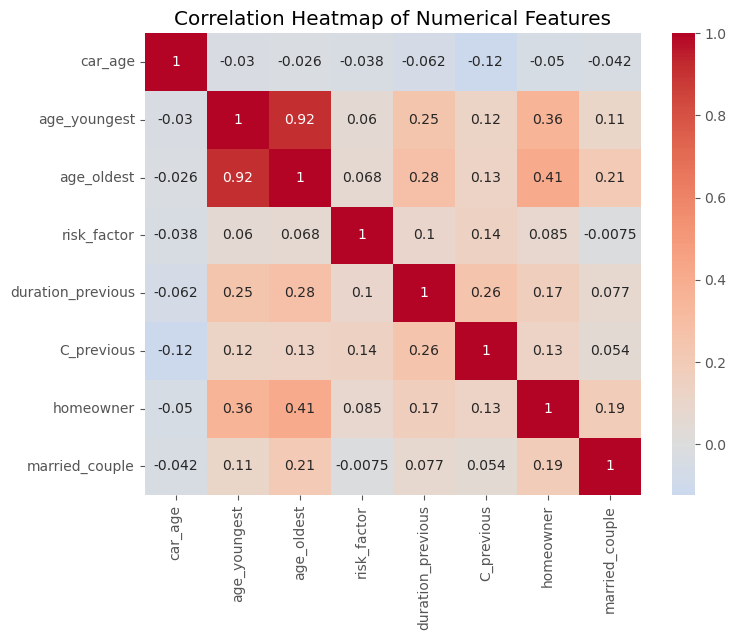

In [13]:
# -----------------------------
# List of numerical predictors in model_region (original columns, exclude Exercise 6 variables)
num_vars = [
    'car_age', 
    'age_youngest', 
    'age_oldest', 
    'risk_factor', 
    'duration_previous', 
    'C_previous', 
    'homeowner', 
    'married_couple'
]

# Create a DataFrame with these features
num_data = train_data[num_vars]

# -----------------------------
# Step 2: Correlation method
# -----------------------------
# Compute correlation matrix
corr_matrix = num_data.corr()

# Show absolute correlations
print("Correlation matrix (absolute values):")
print(corr_matrix.abs())

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

**Answer.**

----------

#### 8.3:

Refit `model_region` after dropping these redundant predictor(s); call this `model_region_no_oldest`.

In [14]:
# Refit model without 'age_oldest' in the formula
model_region_no_oldest = smf.ols(
    formula='cost ~ ' +
            ' + '.join([var for var in sig_vars_region if var != 'age_oldest']) +  # drop age_oldest
            ' + I(age_youngest ** 2)' +
            ' + I(car_age ** 2)' +
            ' + car_value:age_youngest',
    data=train_data  # do NOT drop columns from train_data
).fit()

# Check summary and AIC
print(model_region_no_oldest.summary())
print("AIC:", model_region_no_oldest.aic)


                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     178.9
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:48   Log-Likelihood:                -62231.
No. Observations:               12348   AIC:                         1.245e+05
Df Residuals:                   12306   BIC:                         1.249e+05
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

**Answer.**

----------

#### 8.4

What would you do to diagnose the `model_region_no_oldest` fit? What does this diagnosis suggest to you? (Hint: try plotting the residuals in various ways.)

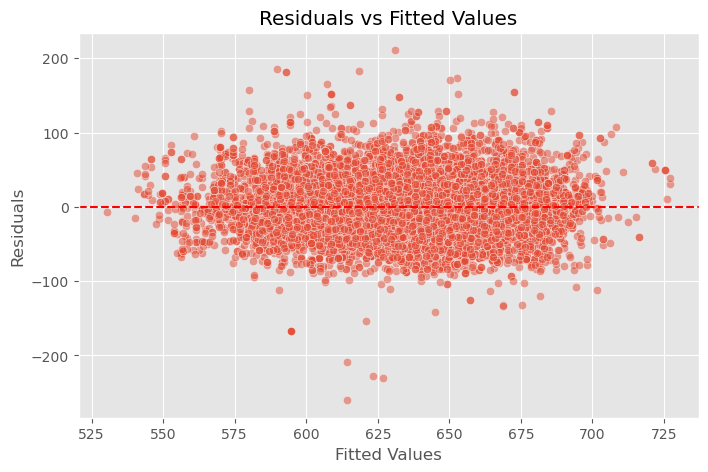

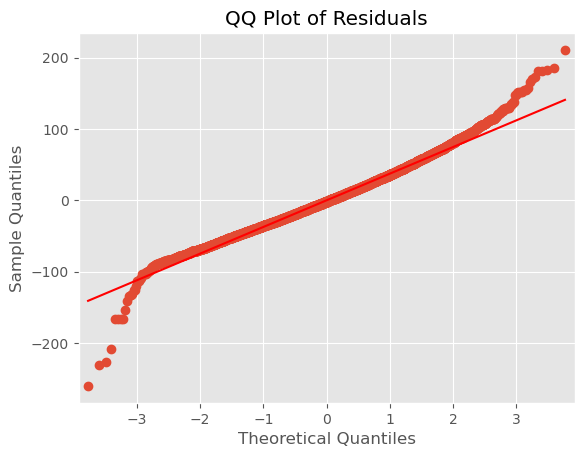

In [15]:
residuals = model_region_no_oldest.resid
fitted = model_region_no_oldest.fittedvalues

# Plot residuals vs fitted values
plt.figure(figsize=(8,5))
sns.scatterplot(x=fitted, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

sm.qqplot(residuals, line='s')  # line='45' adds the reference line
plt.title("QQ Plot of Residuals")
plt.show()

**Answer.**

----------

### Exercise 9:

#### 9.1

Find the best Box-Cox transformation of `cost` used to fit `model_region_no_oldest`. What value do you get?

In [16]:

from scipy import stats
import numpy as np

y = train_data['cost']  # response variable must be positive
y_boxcox, best_lambda = stats.boxcox(y)

print("Best Box-Cox lambda:", best_lambda)


Best Box-Cox lambda: 0.4865339880408509


**Answer.**

----------

#### 9.2

Refit `model_region_no_oldest`, but now with the transformation as suggested by the Box-Cox. Call it `model_region_no_oldest_box_cox`.

In [17]:
# Add Box-Cox transformed response
train_data['cost_boxcox'], best_lambda = stats.boxcox(train_data['cost'])

# Refit model without 'age_oldest' using transformed response
model_region_no_oldest_box_cox = smf.ols(
    formula='cost_boxcox ~ ' +
            ' + '.join([var for var in sig_vars_region if var != 'age_oldest']) +
            ' + I(age_youngest ** 2)' +
            ' + I(car_age ** 2)' +
            ' + car_value:age_youngest',
    data=train_data
).fit()
print(model_region_no_oldest_box_cox.summary())

                            OLS Regression Results                            
Dep. Variable:            cost_boxcox   R-squared:                       0.375
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     180.4
Date:                Thu, 05 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:41:48   Log-Likelihood:                -21305.
No. Observations:               12348   AIC:                         4.269e+04
Df Residuals:                   12306   BIC:                         4.301e+04
Df Model:                          41                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

**Answer.**

----------

## Conclusion

In this, you practiced creating linear models using `statsmodels` and iteratively trimming the input variables to go from including all the variables in the dataset to using only the most relevant variables. You excluded those variables that were statistically insignificant and removed those that had high correlation. Finally, we performed some feature engineering in an attempt to remove some tail behavior that deviates from the normal distribution to better fit our linear model. In the end, we had a very minimal model that contained variables that other insurance companies use to charge premiums that gave us insight on how we can better serve a niche population. 